In [20]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


In [10]:
# 1. 加载数据
df = pd.read_csv('Combined_Data.csv')
# 只选取有径流观测值的行进行模型训练和验证
df_model = df.dropna(subset=['runoff']).copy()
data = df_model[['tmp', 'pre', 'runoff']].values

In [11]:
# 2. 数据归一化 (神经网络对量纲敏感)
scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# 特征包含 tmp, pre, runoff
scaled_features = scaler_x.fit_transform(data) 
# 目标仅为 runoff
scaled_target = scaler_y.fit_transform(data[:, 2].reshape(-1, 1))

In [12]:
# 3. 创建滑动窗口序列 (用过去 12 个月预测第 13 个月)
def create_sequences(data, target, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_features, scaled_target, window_size)

In [15]:
# 4. 划分训练集和测试集 (按时间顺序前 80% 训练)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 5. 构建简单的 LSTM 模型
model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, 3)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# 6. 训练模型
print("开始训练模型...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, verbose=1)

# 获取预测值
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# 反归一化
train_predict_inv = scaler_y.inverse_transform(train_predict)
test_predict_inv = scaler_y.inverse_transform(test_predict)

开始训练模型...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.1018 - val_loss: 0.0587
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0559 - val_loss: 0.0451
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0485 - val_loss: 0.0415
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0434 - val_loss: 0.0368
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0388 - val_loss: 0.0323
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0340 - val_loss: 0.0275
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0281 - val_loss: 0.0215
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0205 - val_loss: 0.0126
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0113 - val_loss: 0.0066
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0082 - val_loss: 0.0070
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0076 - val_loss: 0.0065
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step -

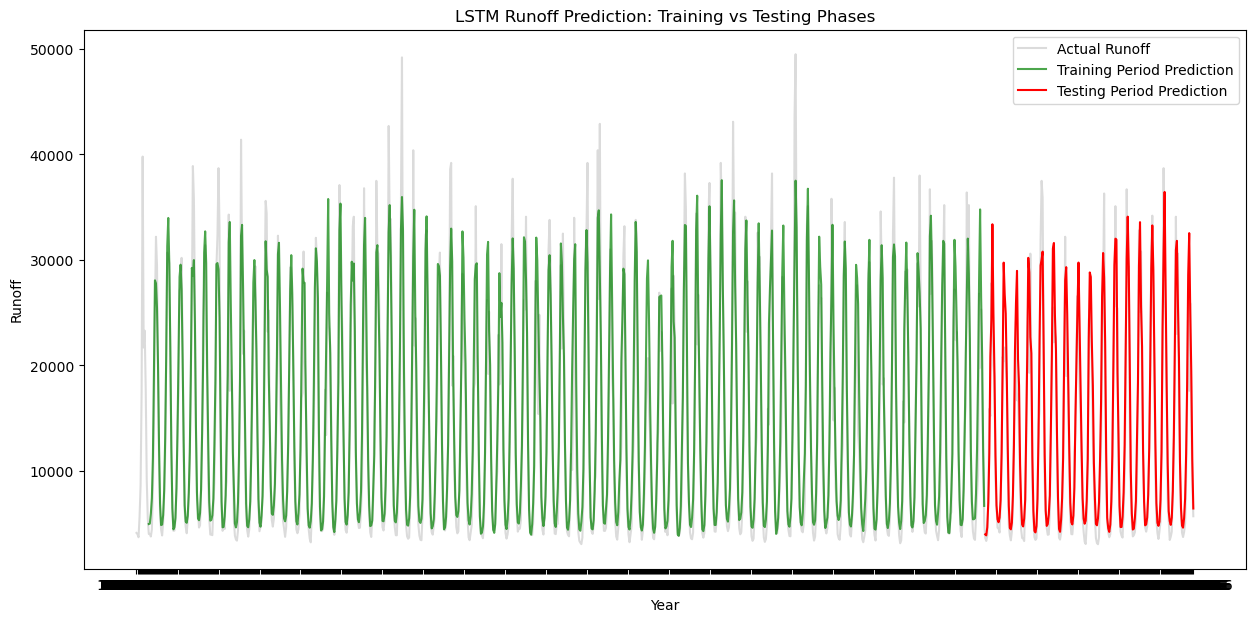

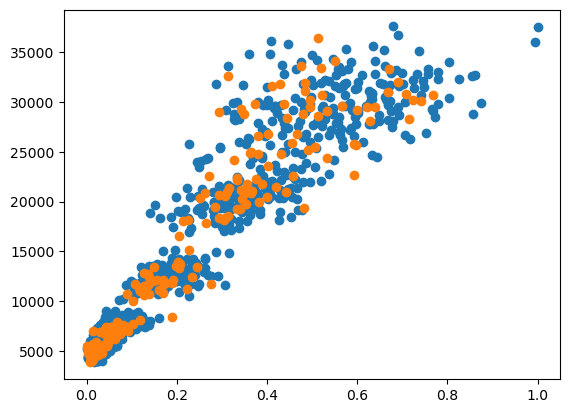

In [16]:
# 7. 绘图对比
plt.figure(figsize=(15, 7))
# 实际值
plt.plot(df_model['time'], df_model['runoff'], label='Actual Runoff', color='lightgrey', alpha=0.8)
# 训练期结果
train_dates = df_model['time'].iloc[window_size : window_size + split]
plt.plot(train_dates, train_predict_inv, label='Training Period Prediction', color='green', linestyle='-', alpha=0.7)
# 测试期结果
test_dates = df_model['time'].iloc[window_size + split :]
plt.plot(test_dates, test_predict_inv, label='Testing Period Prediction', color='red', linestyle='-')

plt.title('LSTM Runoff Prediction: Training vs Testing Phases')
plt.xlabel('Year')
plt.ylabel('Runoff')
plt.legend()
plt.show()

plt.scatter(y_train, train_predict_inv)
plt.scatter(y_test, test_predict_inv)

plt.show()

In [25]:

train_r, _ = pearsonr(y_train, train_predict_inv)
test_r, _ = pearsonr(y_test, test_predict_inv)

print(f"Train R: {train_r[0]:.4f}")
print(f"Test R: {test_r[0]:.4f}")

Train R: 0.9420
Test R: 0.9447
